## EDA For E2E Student Dataset
### PS
- This project undestands how the student's performance is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

### Data Collection
- source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.


## 2.1 Importing Libraries

In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [94]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [95]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [96]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [97]:
df.shape

(1000, 8)

### Dataset Information
- Columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score']
- Shape = (1000, 8)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [98]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Note: No missing values

In [99]:
df.duplicated().sum()

np.int64(0)

Note:- No duplicate Values
#
If found in future then use 
#
```df.drop_duplicates()```

In [100]:
# Finding no of numerical and categorical features
numerical_features = [col for col in df.columns if df[col].dtype != 'object']
categorical_features = [col for col in df.columns if df[col].dtype == 'object']
print('numerical_features:',numerical_features,'\ncategorical_features:',categorical_features)

numerical_features: ['math score', 'reading score', 'writing score'] 
categorical_features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [101]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [102]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [103]:
for cat in categorical_features:
    print(cat,':',df[cat].unique())

gender : ['female' 'male']
race/ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch : ['standard' 'free/reduced']
test preparation course : ['none' 'completed']


Insights:-
- from above data, numerical cols have mean and std in similar range.
- min for math is 0, writing is higher = 10, and for reading is much higher = 17

#### 3.7 Adding cols for total_avg and total_score

In [104]:
"""
    We will use these colums for prediction and then see which one is best out of all the three,
    1. individual scores
    2. average scores
    3. total scores
"""

df['total_score'] = df['reading score'] + df['writing score'] + df['math score']
df['average_score'] = df.total_score/3

df.head(2)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [105]:
# Full marks
full_marks_reading = df[df['reading score']==100]['gender'].count()
full_marks_math = df[df['math score']==100]['gender'].count()
full_marks_writing = df[df['writing score']==100]['gender'].count()

print(f'Number of students with full marks in Maths: {full_marks_math}')
print(f'Number of students with full marks in Writing: {full_marks_writing}')
print(f'Number of students with full marks in Reading: {full_marks_reading}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [106]:
# Less than 20
Less_20_marks_reading = df[df['reading score']<20]['gender'].count()
Less_20_marks_math = df[df['math score']<20]['gender'].count()
Less_20_marks_writing = df[df['writing score']<20]['gender'].count()

print(f'Number of students with less than 20 marks in Maths: {Less_20_marks_math}')
print(f'Number of students with less than 20 marks in Writing: {Less_20_marks_writing}')
print(f'Number of students with less than 20 marks in Reading: {Less_20_marks_reading}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### Observation
- students performance is worst in maths
- students performance is best in reading


# EDA


In [107]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total_score', 'average_score'],
      dtype='object')

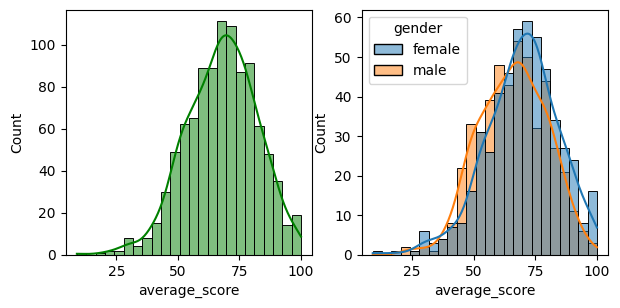

In [108]:
# Histogram & KDE

# Showcasing average scores based on gender
plt.figure(figsize=(7,7))
plt.subplot(2,2,1)
sns.histplot(data=df,x='average_score',kde=True,color='g')
plt.subplot(2,2,2)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

Observation: Girls Scores are more than boys

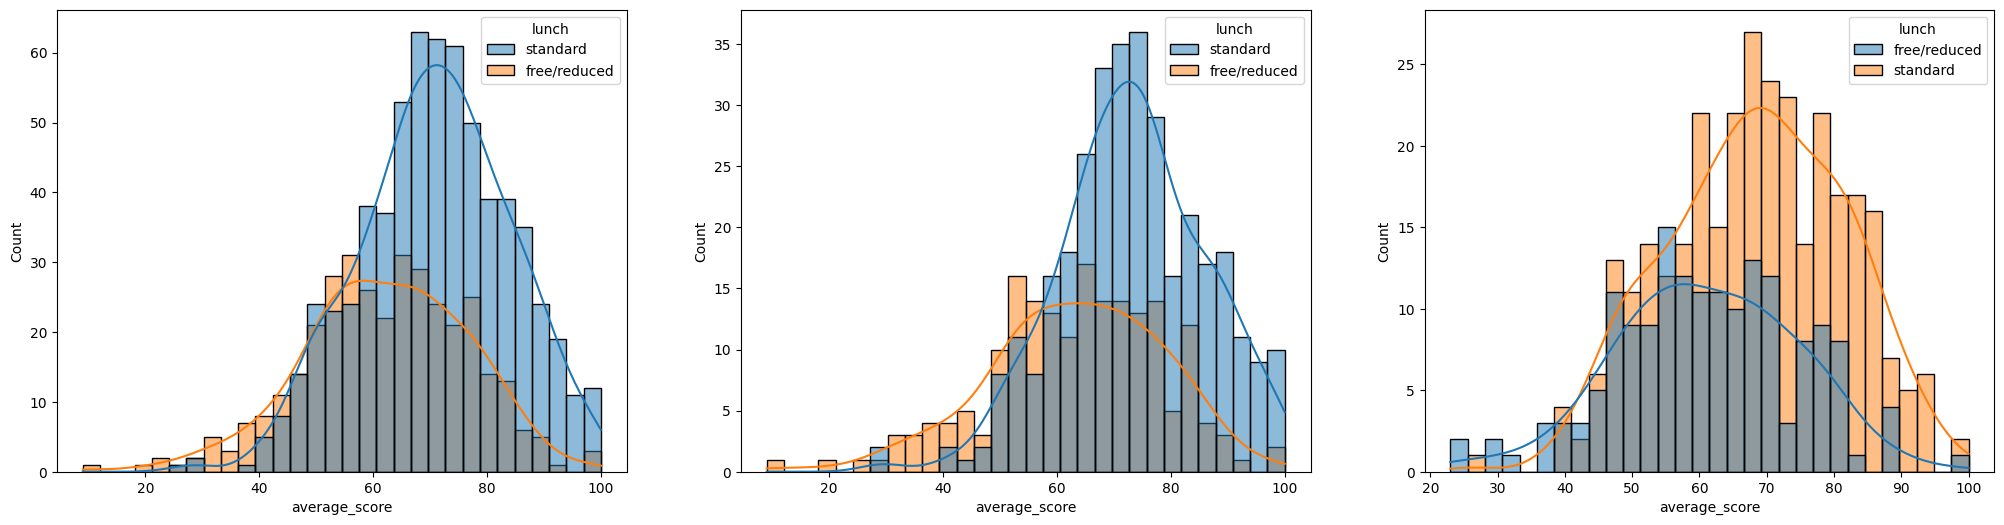

In [109]:
# checking if some fields help in can help in scores
plt.figure(figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average_score',bins=30,kde=True,hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x='average_score',bins=30,kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x='average_score',bins=30,kde=True,hue='lunch')
plt.show()


Observation: Standard Lunch helps in scoring more marks

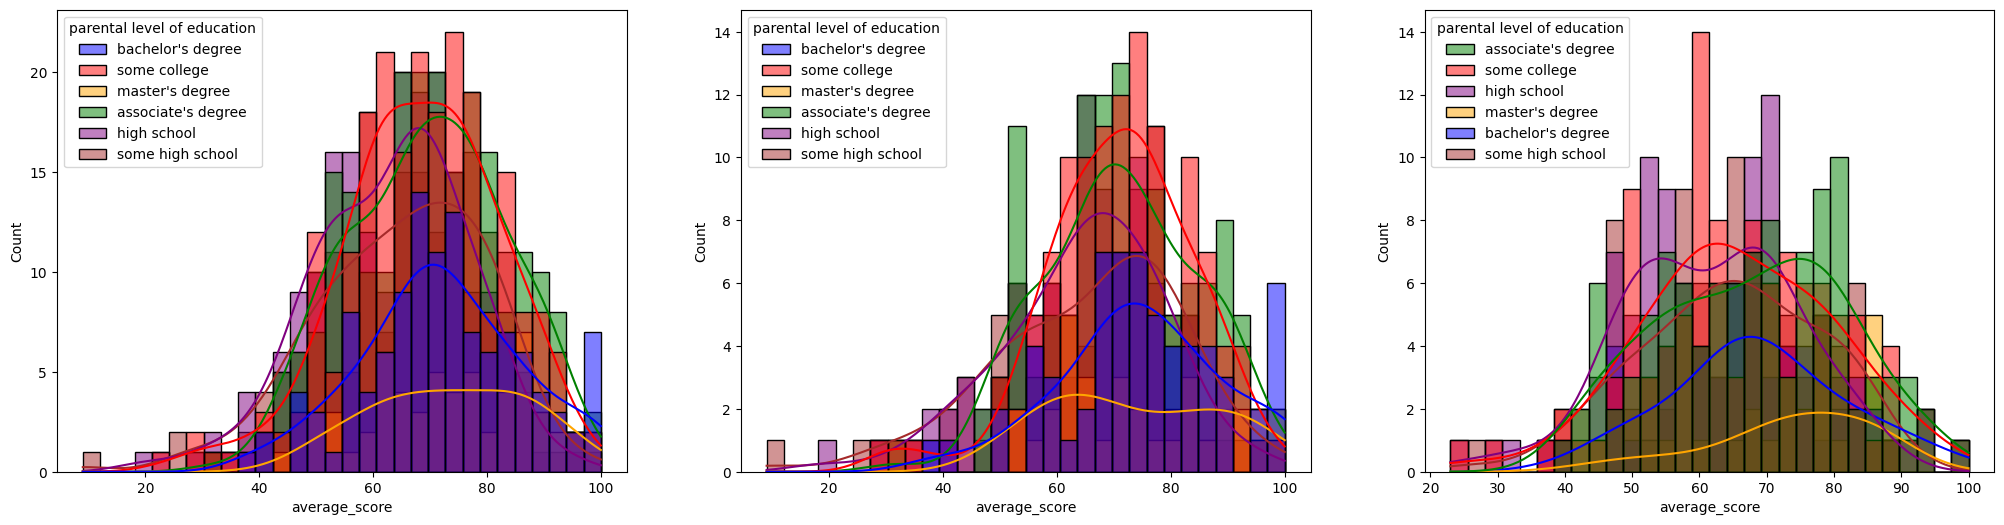

In [110]:
palette = {}
for cat in df['parental level of education'].unique():
    h = abs(hash(cat)) % 0xFFFFFF
    palette[cat] = f"#{h:06x}"

plt.figure(figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average_score',bins=30,kde=True,hue='parental level of education', palette=palatte)
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x='average_score',bins=30, palette=palatte,kde=True,hue='parental level of education')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x='average_score',bins=30, palette=palatte,kde=True,hue='parental level of education')
plt.show()

Observation: parental educaiton is not related to students scores.

<Axes: xlabel='gender', ylabel='average_score'>

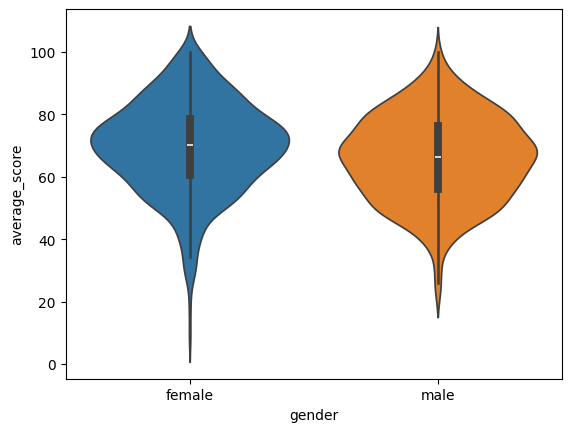

In [111]:
sns.violinplot(data=df,x='gender',y='average_score',hue='gender')

Observations:
1. females have higher freq of scores btw 80-100
2. females have a small amount of low scores btw 0-20
3. both median are spread across 60-80

4.3 Multivariate analysis use pieplot

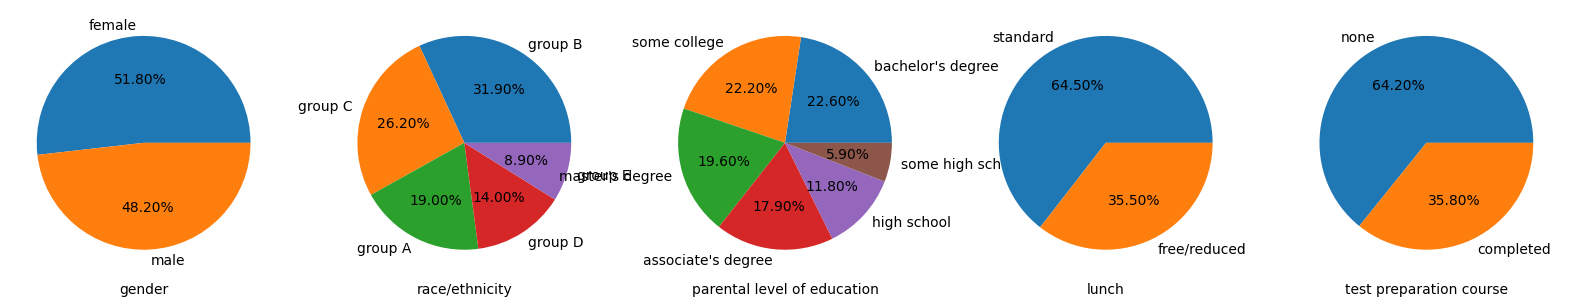

In [124]:
def plot_pie_chart(column:str):
    # Size is the dict of data to plot
    size = df[column].value_counts()
    labels = df[column].unique()
    l_size = len(labels)
    colors = sns.color_palette(n_colors=l_size)
    plt.pie(size,colors = colors,labels=labels,autopct='%.2f%%')
    plt.xlabel(col)


plt.figure(figsize=(20,100))
for i,col in enumerate(categorical_features):
    plt.subplot(1,5,i+1)
    plot_pie_chart(col)
    

Observation:-
- female and male are in same proportions
- group B and C constitute half of the population
- majority of population's parents have a type of clg degree
- population taking standard lunch is twice than free
- population writing exam without completing exam is twice than completing

## Univariate and bivariate analysis for Features


In [198]:
# Univariate
# How is distribution
from typing import List
def univariate_categorical(columns:List[str]):
    no_of_col = len(columns)
    plt.figure(figsize = (12,8*no_of_col))
    for i,column in enumerate(columns):
        plt.subplot(no_of_col,2,2*i+1)
        ax = sns.countplot(x=df[column],data=df,palette='bright',hue=column)
        plt.xticks(rotation=30)

        for container in ax.containers:
            ax.bar_label(container)

        plt.subplot(no_of_col,2,2*i+2)
        size = df[column].value_counts()
        explode = [0.03]*(len(size))
        plt.pie(size,labels=size.index,autopct='%1.1f%%',explode=explode)

def univariate_numerical(columns:List[str]):
    no_of_col = len(columns)
    plt.figure(figsize=(12,5*no_of_col))
    stats = df[columns].describe()
    
    print(stats)
    for i,column in enumerate(columns):
        print('Column Name:', column)
        print('Skewness:',df[column].skew())
        plt.subplot(no_of_col,2,2*i + 1)
        sns.histplot(data=df,x=column,bins=30,kde=True)
        plt.title(f"Histogram - {column}")
        plt.subplot(no_of_col,2,2*i+2)
        sns.boxplot(data=df,y=column)
        plt.title(f"box plot - {column}")
        plt.plot
        

### 4.1 Univariate

### Numerical Features
- 4.1.1 math score 
- 4.1.2 reading score
- 4.1.3 writing score
- 4.1.4 total_score
- 4.1.5 average_score


       math score  reading score  writing score  total_score  average_score
count  1000.00000    1000.000000    1000.000000  1000.000000    1000.000000
mean     66.08900      69.169000      68.054000   203.312000      67.770667
std      15.16308      14.600192      15.195657    42.771978      14.257326
min       0.00000      17.000000      10.000000    27.000000       9.000000
25%      57.00000      59.000000      57.750000   175.000000      58.333333
50%      66.00000      70.000000      69.000000   205.000000      68.333333
75%      77.00000      79.000000      79.000000   233.000000      77.666667
max     100.00000     100.000000     100.000000   300.000000     100.000000
Column Name: math score
Skewness: -0.27893514909431694
Column Name: reading score
Skewness: -0.25910451810923063
Column Name: writing score
Skewness: -0.28944397150761897
Column Name: total_score
Skewness: -0.2990571175016888
Column Name: average_score
Skewness: -0.29905711750168584


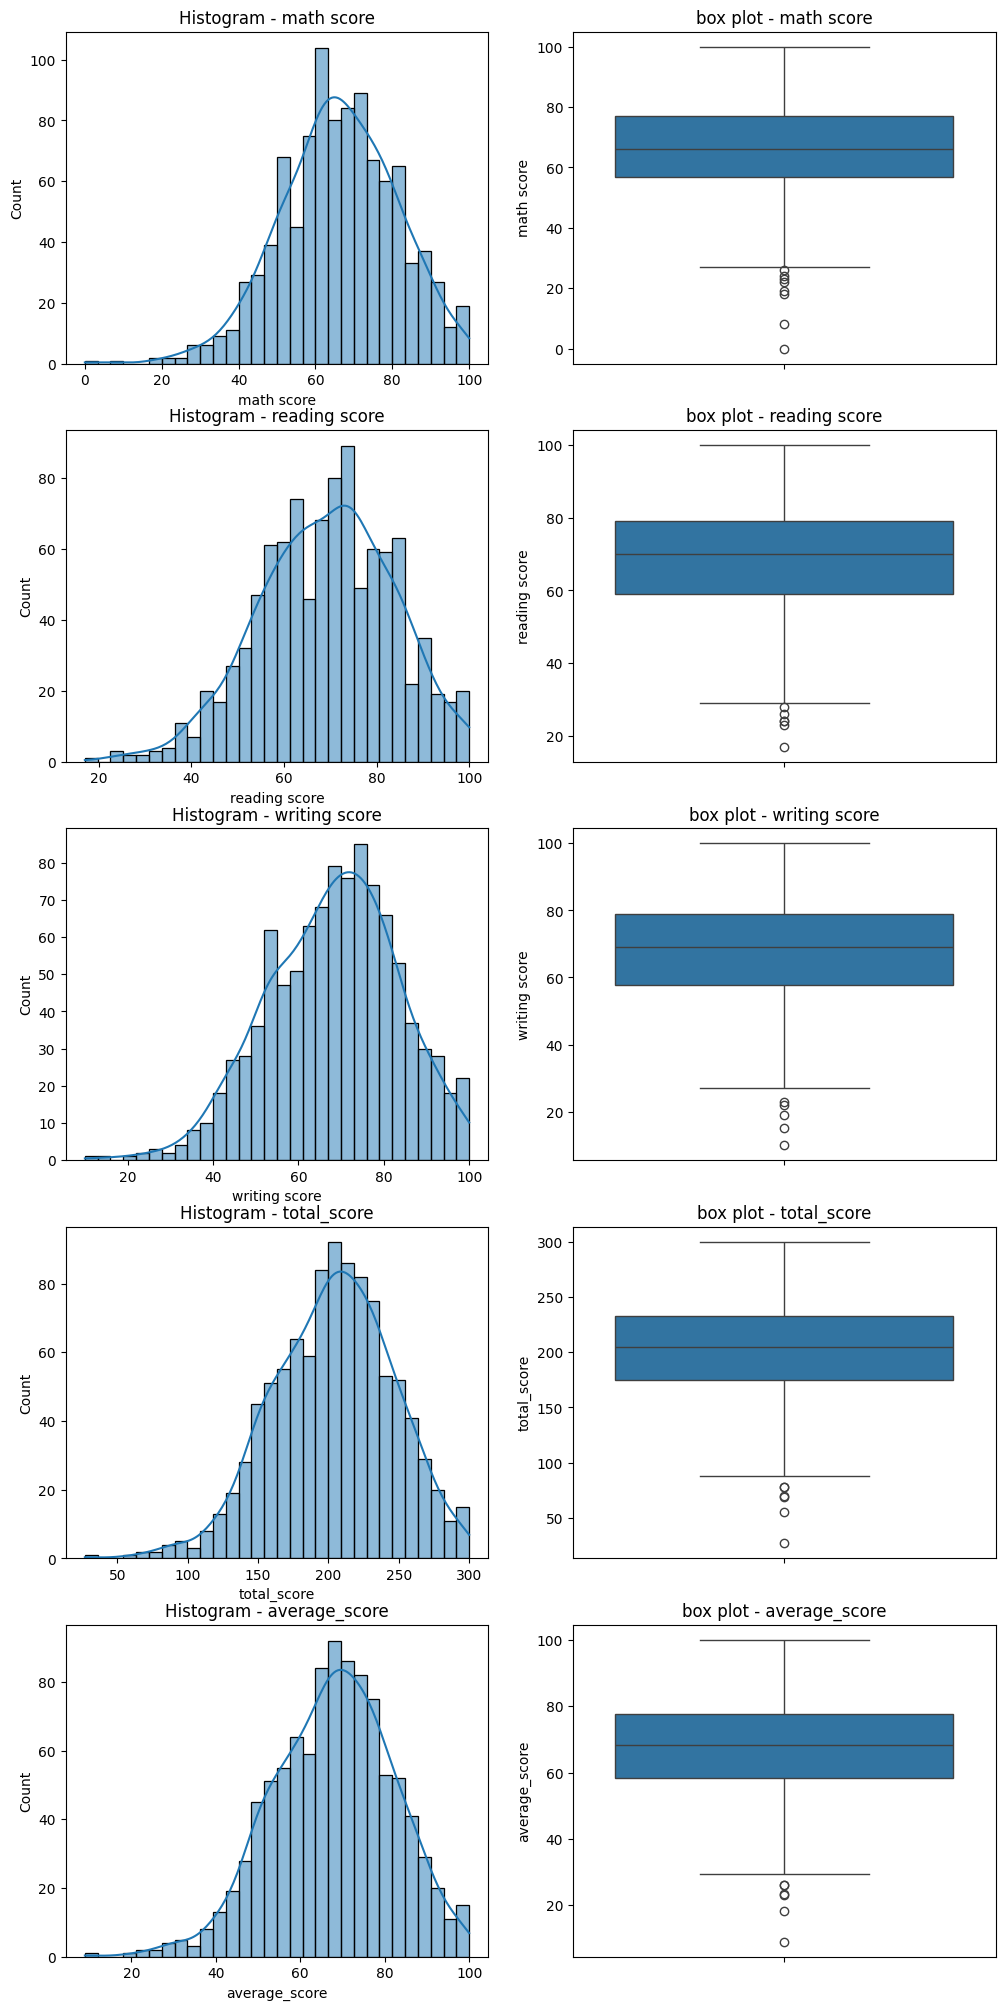

In [167]:
numerical_columns = [x for x in df.columns if df[x].dtype!='object']
univariate_numerical(numerical_columns)

Observation:- 
- left skewed but not too much
- some indignificant outliers

## Categorical
- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course

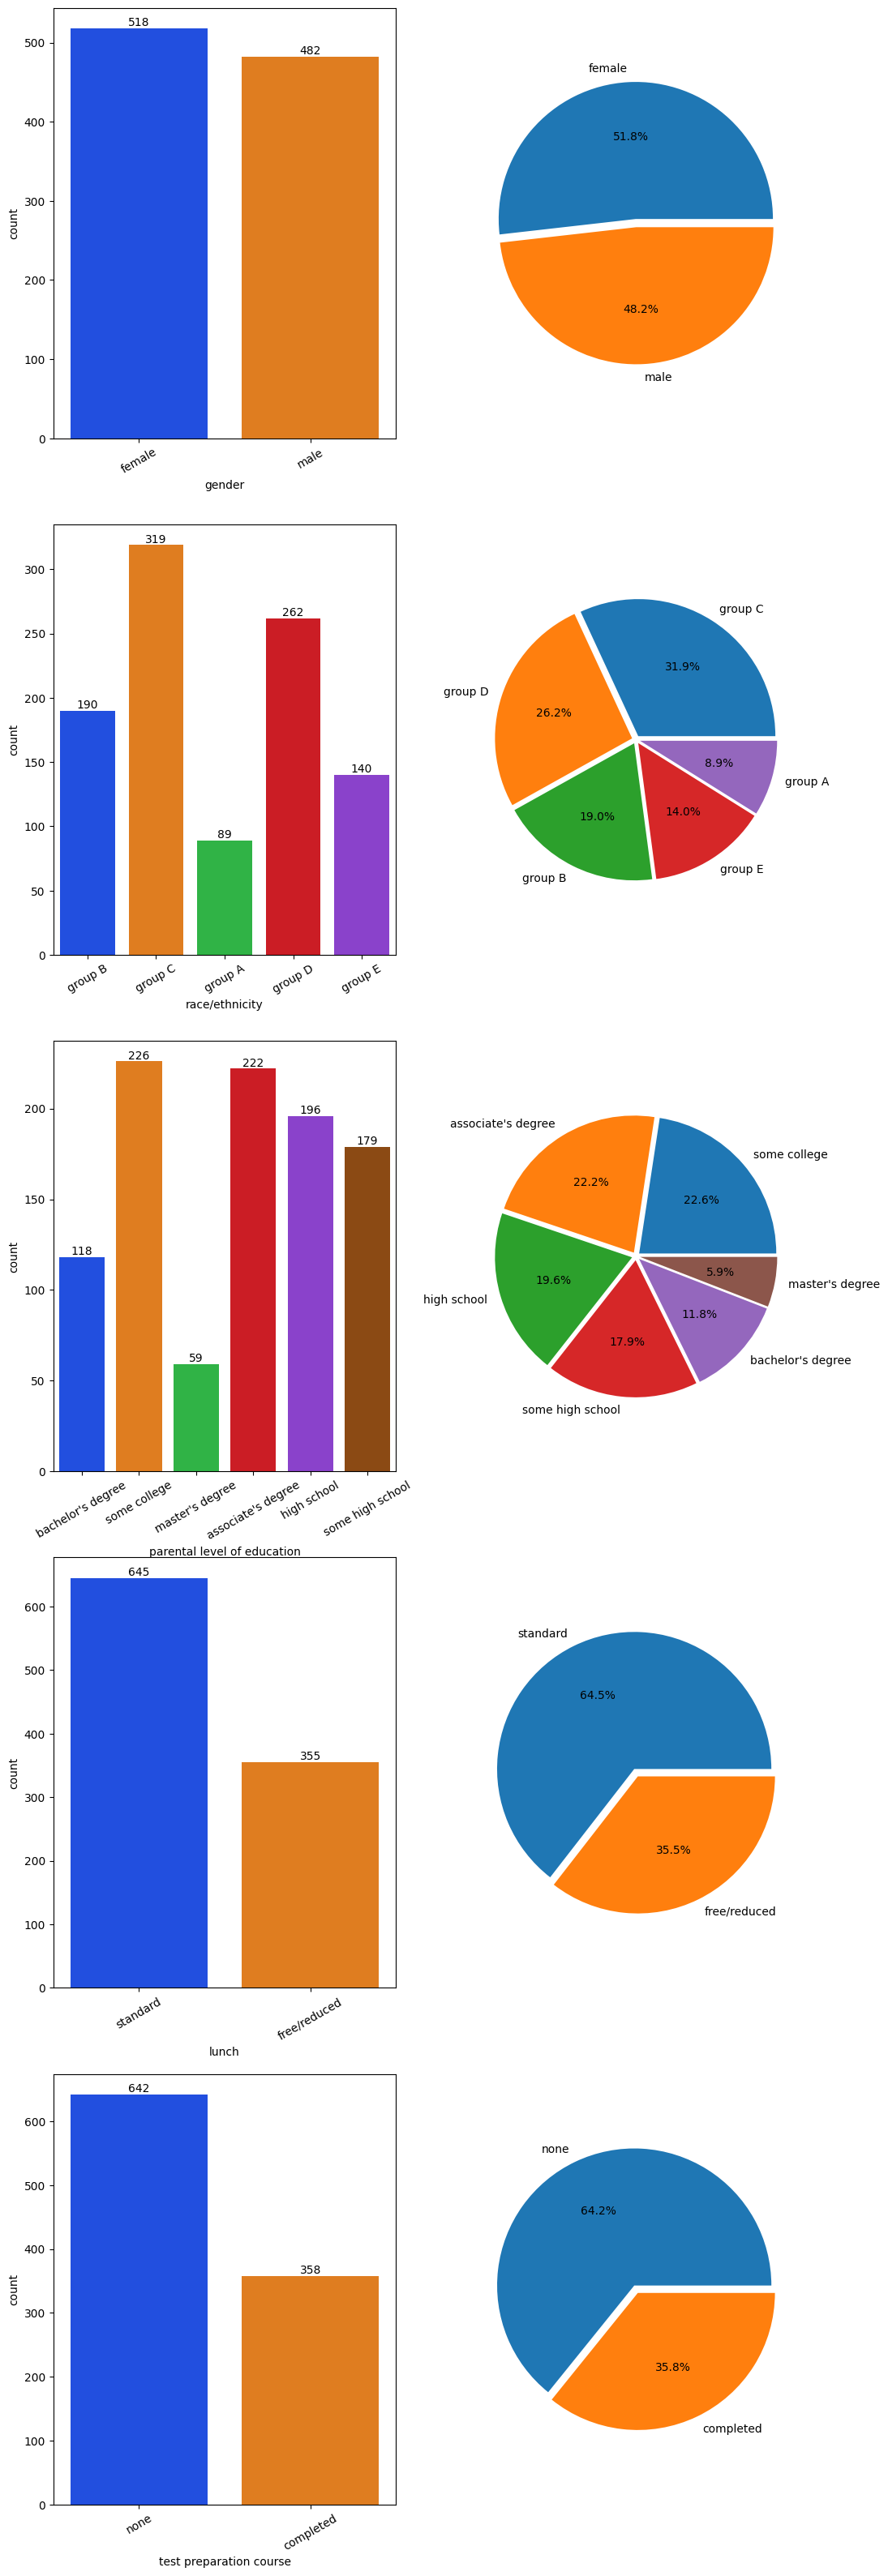

In [199]:
categorical_columns = [x for x in df.columns if df[x].dtype=='object']

univariate_categorical(categorical_columns)


## Bivariate Analysis
Since we have all the feature col as categorical and target as numerical we will check 
- cat vs num

- 4.2.1 average_score
    - 4.2.1.1 gender
    - 4.2.1.2 race/ethnicity
    - 4.2.1.3 parental level of education
    - 4.2.1.4 lunch
    - 4.2.1.5 test preparation course

In [207]:
def bivariate_analysis(target:str,columns:List[str]):
    no_of_col = len(columns)
    plt.figure(figsize=(12,5*no_of_col))
    for i,column in enumerate(columns):
        plt.subplot(no_of_col,1,i+1)
        sns.violinplot(data=df,y=target,hue=column)
        plt.title(column)


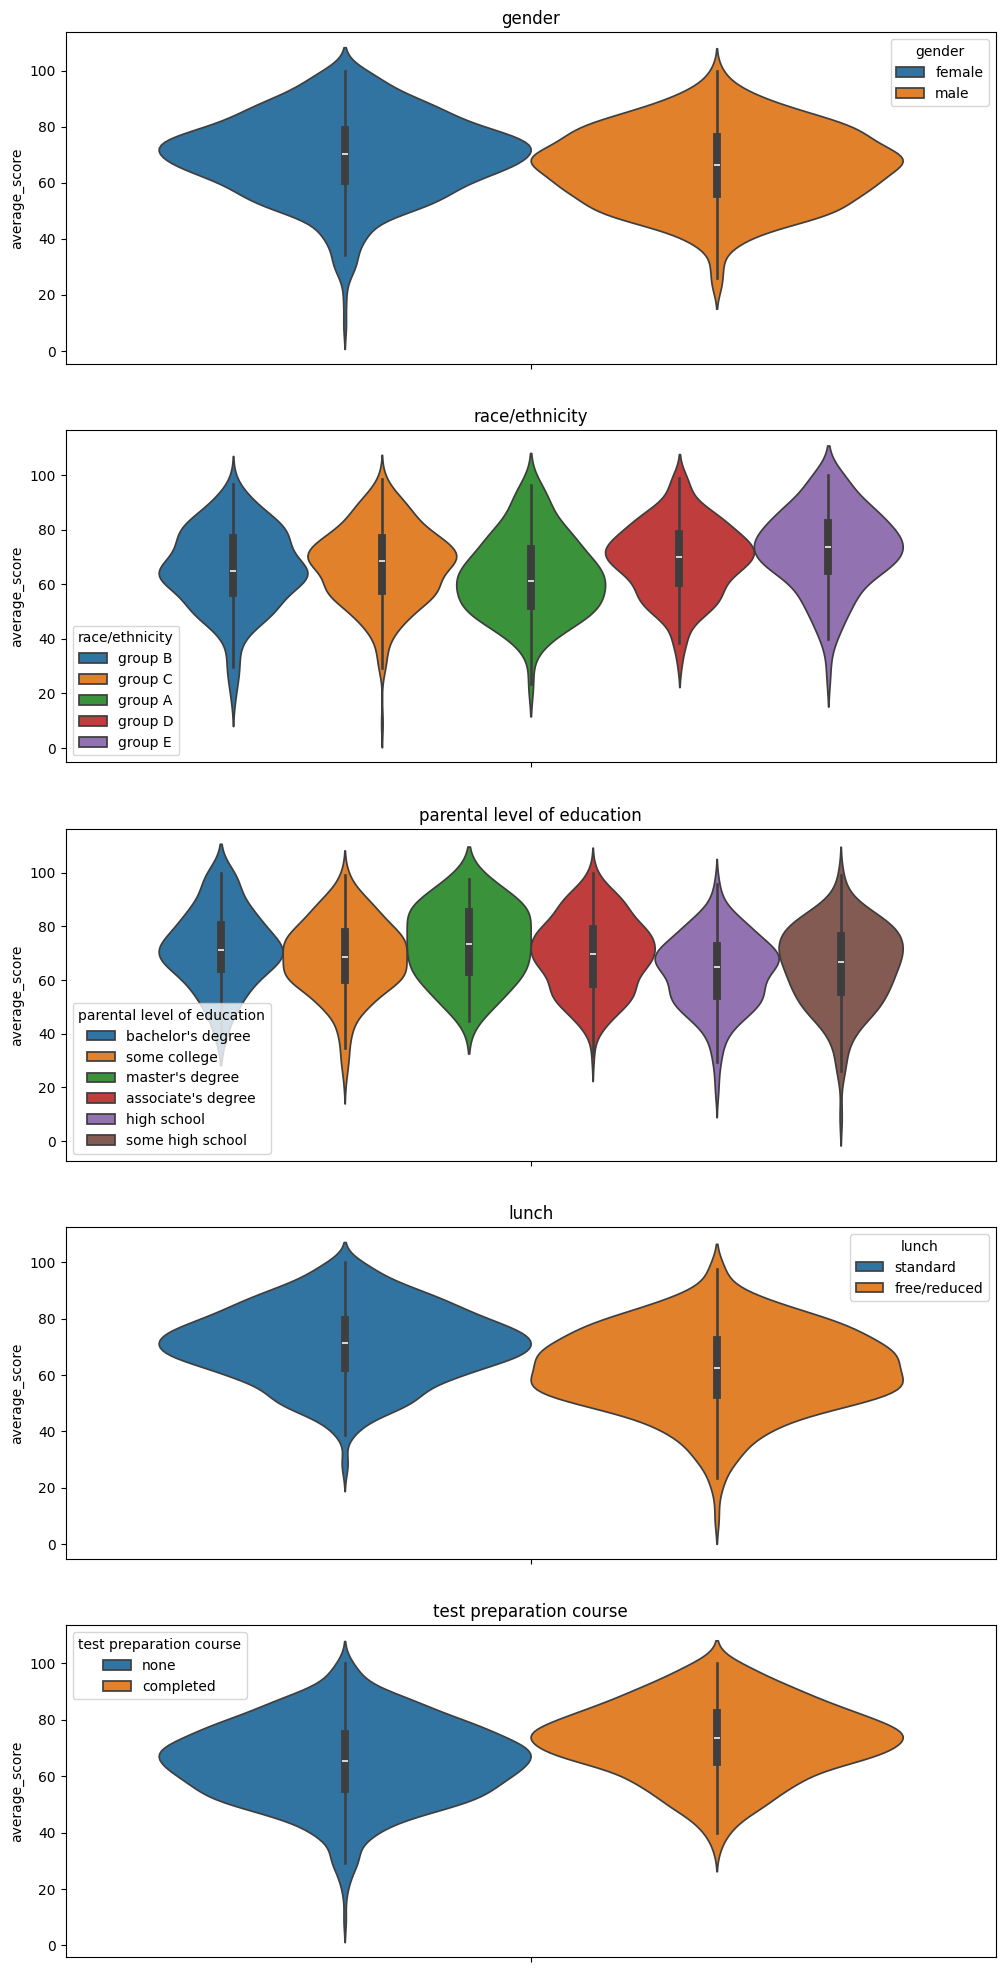

In [208]:
bivariate_analysis('average_score',categorical_columns)

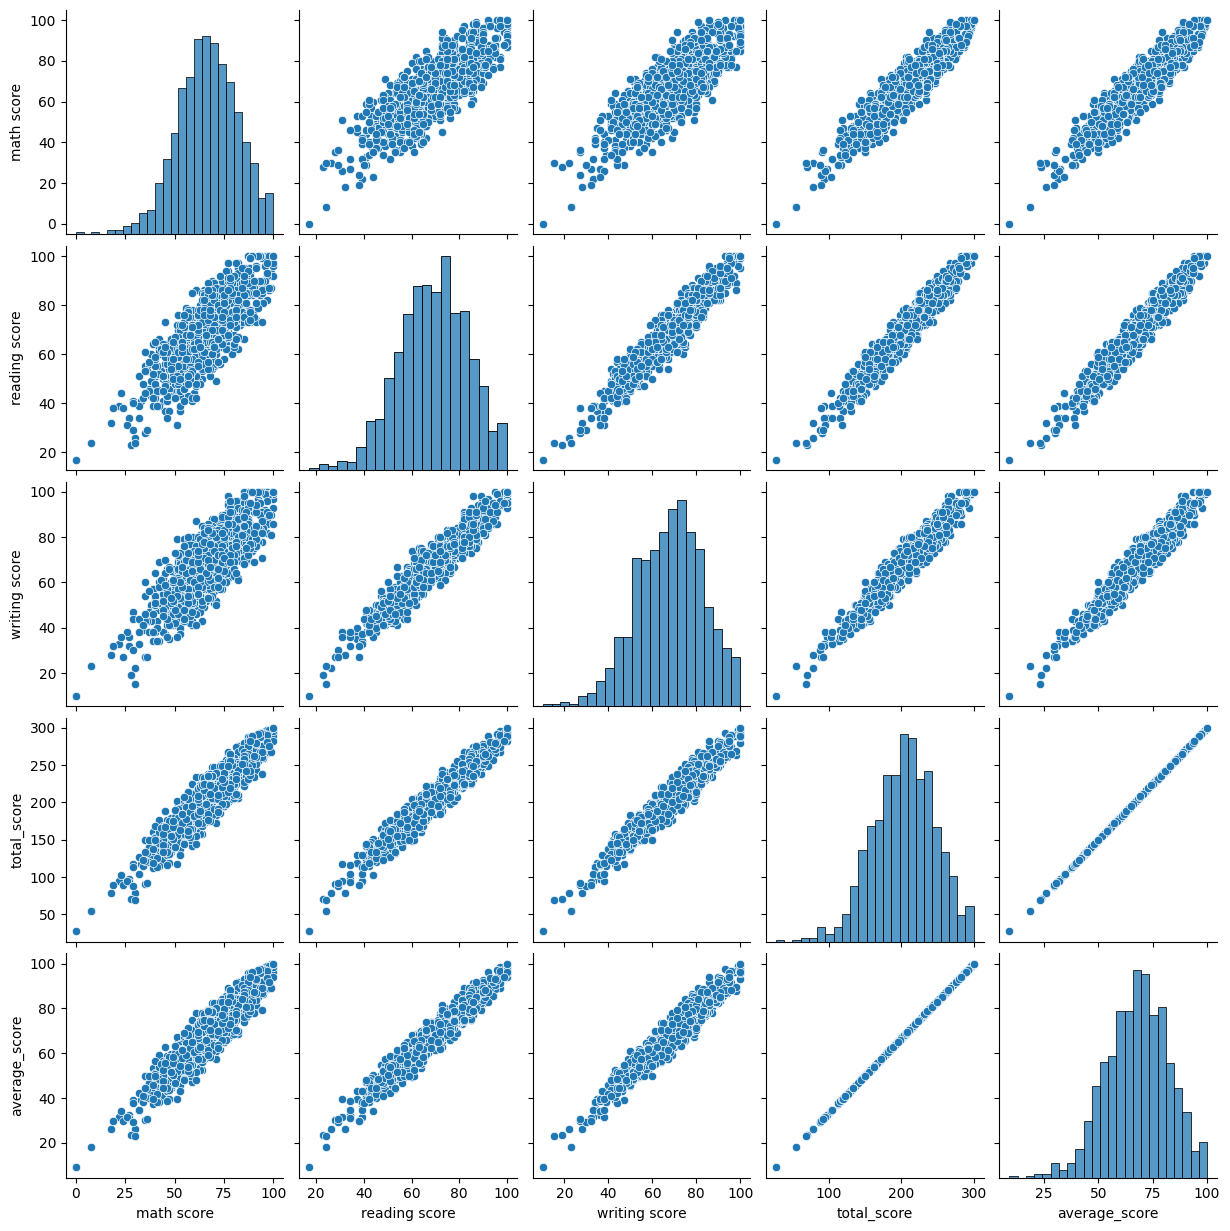

In [ ]:
sns.pairplot(data=df)

Observation: Reading and writing scores are strongly correlated, indicating similar skill dimensions